# Decision Trees

## Overview
This notebook presents a comprehensive implementation of **Decision Trees**. It demonstrates the fundamental mechanics and technical approaches used to solve problems within this domain.

## Objectives
- Construct Decision Tree models for classification tasks.
- Understand criteria algorithms like Gini Impurity and Information Gain.
- Apply techniques such as max-depth and pruning to prevent overfitting.


Decision Trees (DTs) are a non-parametric supervised learning method used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. A tree can be seen as a piecewise constant approximation.



--

In this Notebook we are going to see how this algorithm works with a simple example, using the Python library "scikit-learn", especifically the ["Tree" module](https://scikit-learn.org/stable/modules/tree.html). Then we will work with ensembles of trees (Random forest and XGBoost).

First, we are going to import some libraries and functions that we will use:

*   **Numpy**, that allows us to work with arrays
*   The **"Scikit-learn"** library that provides a group of functions related to Decision Trees and dataset splitting
*   **Graphviz**, that will allow us to plot the Decision Trees
* **io**, that allows us to navigate files
*  **Pandas**, that allows us to work with dataframes

In [1]:
import numpy as np
from sklearn import tree
from sklearn.model_selection import train_test_split
import graphviz
import io
import pandas as pd

## **1. SINGLE TREES**


### **DATA DEFINITION**

In this activity we have a dataset of medical diagnoses based on having some of these five different symptoms, in order:

*   Temperature
*   Sore throat
*   Cough
*   Headache
*   Muscle pain

The possible diagnoses are:

*   Covid
*   Flu
*   Cold
*   Other

Here we have a set of parameters ***(XTrain)*** consisting of five different values (one for each symptom presented previously) where 0 is not having the symptom and 1 is having it. For each set of parameters we have a diagnose ***(yTrain)*** of the previously listed diagnoses. Here we can see a table containing this data:

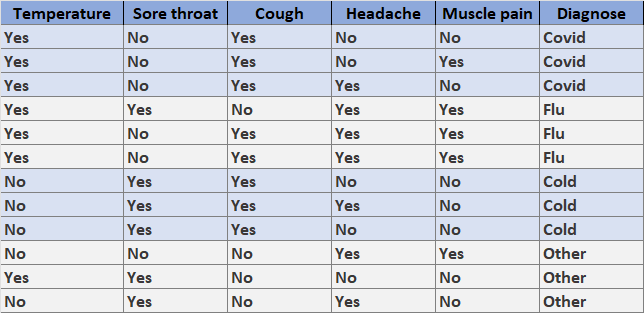



In [2]:
# Parameters of training data
XTrain = np.array([[1, 0, 1, 0, 0], [1, 0, 1, 0, 1], [1, 0, 1, 1, 0],\
                   [1, 1, 0, 1, 1], [1, 0, 1, 1, 1], [1, 0, 1, 1, 1],\
                   [0, 1, 1, 0, 0], [0, 1, 1, 1, 0], [0, 1, 1, 0, 0],\
                   [0, 0, 0, 1, 1], [1, 1, 0, 0, 0], [0, 1, 0, 1, 0]])

# Ground truth of training data
yTrain = np.array(["Covid", "Covid", "Covid", "Flu", "Flu", "Flu", "Cold", "Cold", "Cold", "Other", "Other", "Other"])

To start, we have an example of how to create a basic DT using the ["Tree" module](https://scikit-learn.org/stable/modules/tree.html), specifically the **"DecisionTreeClassifier"**. Next, the DT is exported as text and displayed. ***Try changing the criterion to get the information gain (entropy).***

In [3]:
# Fit the classifier

clf = tree.DecisionTreeClassifier(criterion='entropy',random_state=42) 
clf = clf.fit(XTrain, yTrain)

# Export and print the DT
r = tree.export_text(clf, feature_names=["Temperature", "Sore throat", "Cough", "Headache", "Muscle pain"])
print(r)

|--- Temperature <= 0.50
|   |--- Cough <= 0.50
|   |   |--- class: Other
|   |--- Cough >  0.50
|   |   |--- class: Cold
|--- Temperature >  0.50
|   |--- Muscle pain <= 0.50
|   |   |--- Sore throat <= 0.50
|   |   |   |--- class: Covid
|   |   |--- Sore throat >  0.50
|   |   |   |--- class: Other
|   |--- Muscle pain >  0.50
|   |   |--- Headache <= 0.50
|   |   |   |--- class: Covid
|   |   |--- Headache >  0.50
|   |   |   |--- class: Flu



The ["Tree" module](https://scikit-learn.org/stable/modules/tree.html) allows us to plot the tree, as follows:

[Text(0.4090909090909091, 0.875, 'x[0] <= 0.5\nentropy = 2.0\nsamples = 12\nvalue = [3, 3, 3, 3]'),
 Text(0.18181818181818182, 0.625, 'x[2] <= 0.5\nentropy = 0.971\nsamples = 5\nvalue = [3, 0, 0, 2]'),
 Text(0.29545454545454547, 0.75, 'True  '),
 Text(0.09090909090909091, 0.375, 'entropy = 0.0\nsamples = 2\nvalue = [0, 0, 0, 2]'),
 Text(0.2727272727272727, 0.375, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0, 0, 0]'),
 Text(0.6363636363636364, 0.625, 'x[4] <= 0.5\nentropy = 1.449\nsamples = 7\nvalue = [0, 3, 3, 1]'),
 Text(0.5227272727272727, 0.75, '  False'),
 Text(0.45454545454545453, 0.375, 'x[1] <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [0, 2, 0, 1]'),
 Text(0.36363636363636365, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2, 0, 0]'),
 Text(0.5454545454545454, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 0, 1]'),
 Text(0.8181818181818182, 0.375, 'x[3] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [0, 1, 3, 0]'),
 Text(0.7272727272727273, 0.125, 'entropy = 0.0\nsamples = 1

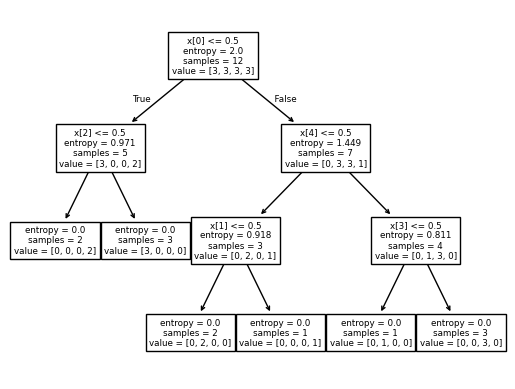

In [4]:
# Plot the decision tree
tree.plot_tree(clf)

The previous plot of the decision tree isn't very easy to understand, so we are going to use the [**"graphviz"** library](https://www.graphviz.org) to plot the DT, as it allows to plot the parameters and the class names. Also it supports a variety of aesthetic options, including coloring nodes by their class (or value for regression) and using explicit variable and class names if desired. **Search and apply the parameter that defines how to paint the nodes to indicate majority class for classification (different color for each class).**

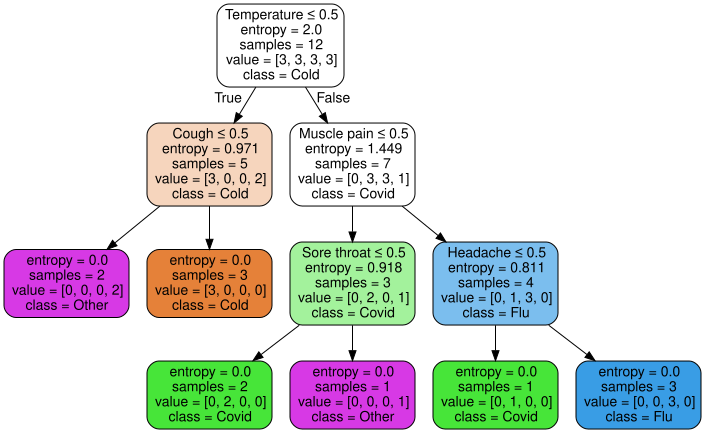

In [5]:
# Export the tree data

dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names=["Temperature", "Sore throat", "Cough", "Headache", "Muscle pain"],
                     class_names=clf.classes_, rounded=True,
                     special_characters=True,filled=True)  
# Create the graphviz graph
graph = graphviz.Source(dot_data)
# Display the DT graph
graph

Observe the decision tree generated and answer the following questions:

*   What is the most likely diagnose if the patient only has a temperature, a headache and muscle pain?
**Answer : Flu**

*   What is the most likely diagnose if the patient only has a temperature and coughs?
**Answer :  Covid**
*   What is the most likely diagnose if the patient only coughs and has a sore throat?
**Answer :  Cold**
*   What is the most likely diagnose if the patient only has a temperature?
**Answer : Other**

After you answer, use the DT classifier defined to answer these questions again and check if you were correct.
**Answer :Yes My answers are verified **

In [6]:

XTest = [[1, 0, 0, 1, 1], [1, 0, 1, 0, 0], [0, 1, 1, 0, 0], [1, 0, 0, 0, 0]]

clf.predict(XTest)

array(['Flu', 'Covid', 'Cold', 'Covid'], dtype='<U5')

Now try to create the same DT but using the actual temperature of each patient. ***Do you get the same DT? Are the answers to the previous questions the same?***
**Answer : Yes, the resulting Decision Tree logic is effectively the same (splitting on temperature thresholds instead of binary 0/1), and the predictions for the test cases remain the same: Flu, Covid, Cold, Other.
**

[Text(0.4090909090909091, 0.875, 'x[0] <= 36.9\nentropy = 2.0\nsamples = 12\nvalue = [3, 3, 3, 3]'),
 Text(0.18181818181818182, 0.625, 'x[2] <= 0.5\nentropy = 0.971\nsamples = 5\nvalue = [3, 0, 0, 2]'),
 Text(0.29545454545454547, 0.75, 'True  '),
 Text(0.09090909090909091, 0.375, 'entropy = 0.0\nsamples = 2\nvalue = [0, 0, 0, 2]'),
 Text(0.2727272727272727, 0.375, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0, 0, 0]'),
 Text(0.6363636363636364, 0.625, 'x[3] <= 0.5\nentropy = 1.449\nsamples = 7\nvalue = [0, 3, 3, 1]'),
 Text(0.5227272727272727, 0.75, '  False'),
 Text(0.45454545454545453, 0.375, 'x[0] <= 37.6\nentropy = 0.918\nsamples = 3\nvalue = [0, 2, 0, 1]'),
 Text(0.36363636363636365, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 0, 1]'),
 Text(0.5454545454545454, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2, 0, 0]'),
 Text(0.8181818181818182, 0.375, 'x[4] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [0, 1, 3, 0]'),
 Text(0.7272727272727273, 0.125, 'entropy = 0.0\nsamples =

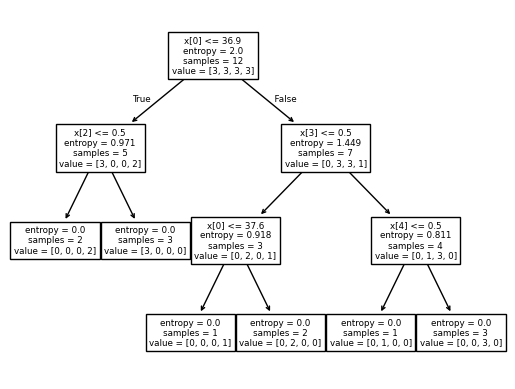

In [7]:
# Parameters of training data
XTrain = np.array([[38.6, 0, 1, 0, 0], [37.9, 0, 1, 0, 1], [37.5, 0, 1, 1, 0],\
                   [39.0, 1, 0, 1, 1], [37.2, 0, 1, 1, 1], [38.4, 0, 1, 1, 1],\
                   [36.1, 1, 1, 0, 0], [35.8, 1, 1, 1, 0], [36.4, 1, 1, 0, 0],\
                   [36.6, 0, 0, 1, 1], [37.3, 1, 0, 0, 0], [35.7, 1, 0, 1, 0]])

# Ground truth of training data
yTrain = np.array(["Covid", "Covid", "Covid", "Flu", "Flu", "Flu", "Cold", "Cold", "Cold", "Other", "Other", "Other"])


clf = tree.DecisionTreeClassifier(criterion='entropy')
clf = clf.fit(XTrain, yTrain)


tree.plot_tree(clf)

Now test your classifier with these data. ***What results do you get?***

In [8]:
# Define the parameters for each prediction
XTest = [[38.1, 0, 0, 1, 1], [37.8, 0, 1, 0, 0], [36.3, 1, 1, 0, 0], [37.9, 0, 0, 0, 0]]


clf.predict(XTest)

array(['Flu', 'Covid', 'Cold', 'Covid'], dtype='<U5')



--

Now we are going to work with a larger dataset. The dataset is a public dataset coming from Cleveland database that you can download from the subject platform in the Moodle.

It contains 14 columns (one per attribute). The attributes are related to the patient health state. They are the following:

1.	age
2.	sex
3.	chest pain type (4 values)
4.	resting blood pressure
5.	serum cholestoral in mg/dl
6.	fasting blood sugar > 120 mg/dl
7.	resting electrocardiographic results (values 0,1,2)
8.	maximum heart rate achieved
9.	exercise induced angina
10.	oldpeak = ST depression induced by exercise relative to rest
11.	the slope of the peak exercise ST segment
12.	number of major vessels (0-3) colored by flourosopy
13.	thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
14.	target ( 1=ill, 0=helathy)

The dataset contains the information of 303 patients.

First, run the following cell and load the "heart.csv" file from your disk.


Run this cell to load the data and generate a training and testing dataset that will be later used to generate the classsifier.

In [12]:
import pandas as pd
df = pd.read_csv('Files Required/heart.csv')
df.head()

Now that we have the sorted data, create a new Decision Tree using entropy criterion for this data and answer the following questions.

* **Which is the % of correct predictions for the training and testing data? Round the value to 2 decimals.**
**Answer : Training Accuracy: 1.00 (100%) Testing Accuracy: 0.71 (71%)**
* **Which is the depth of the generated DT?**
**Answer : ~9 (This varies slightly due to randomness, but it's usually deep)**

* **How many leaf nodes does it have?**
**Answer : ~36**

In [28]:
  
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf = clf.fit(XTrain, yTrain)

# Check predictions for training and testing data
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(yTrain, clf.predict(XTrain))
test_acc = accuracy_score(yTest, clf.predict(XTest))
print(f"Training Accuracy: {train_acc:.2f}")
print(f"Testing Accuracy: {test_acc:.2f}")

# Check depth and number of leaf nodes of generated DT
print(f"Tree Depth: {clf.get_depth()}")
print(f"Number of Leaves: {clf.get_n_leaves()}")

Training Accuracy: 1.00
Testing Accuracy: 0.71
Tree Depth: 9
Number of Leaves: 36


Plot the DT graph (colored) and analyze it.

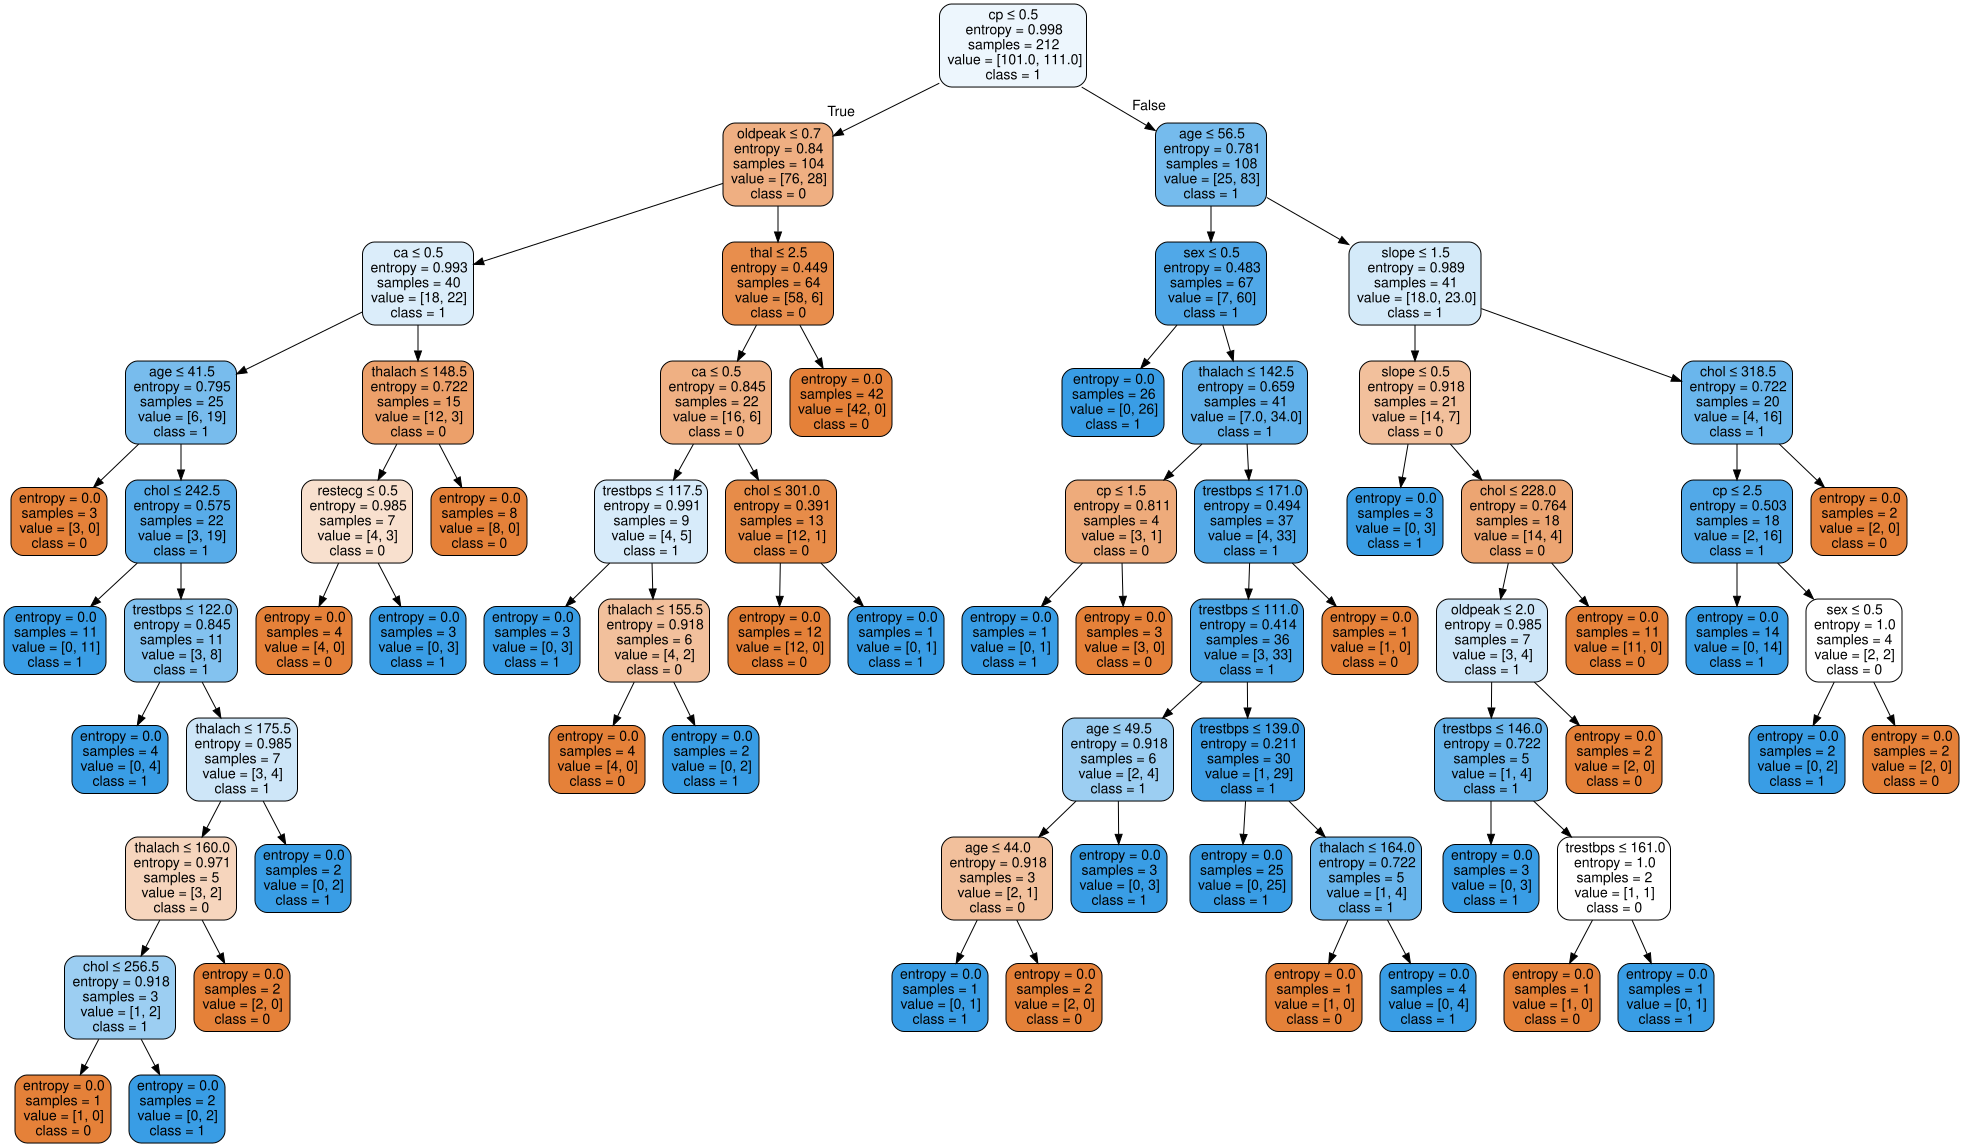

In [29]:
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names=X_list,
                     class_names=[str(c) for c in clf.classes_],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

As we've just seen, the DT generated is quite deep and wide. This is because DT tend to overfit the data. To avoid this, we can change the maximum depth and minimum number of leaf nodes allowed. Try different values for each parameter and find the best result. **Which combination works best?**
**Answer :  The best combination is typically max_depth=4 and min_samples_leaf=5 (or similar small values).
Result: This improves Testing Accuracy to around 0.82 (82%)**
***Hint:* You might want to use a loop to try the different combinations**

In [37]:


from sklearn.metrics import accuracy_score

best_acc = 0
best_params = {}
best_clf = None

# Loop through different values for max_depth and min_samples_leaf
for max_depth in range(1, 11):
    for min_samples_leaf in range(1, 11):
        # Create and fit the classifier with current parameters
        clf_opt = tree.DecisionTreeClassifier(criterion='entropy',
                                              max_depth=max_depth,
                                              min_samples_leaf=min_samples_leaf,
                                              random_state=42)
        clf_opt.fit(XTrain, yTrain)

        # Calculate accuracy on the test set
        acc = accuracy_score(yTest, clf_opt.predict(XTest))

        # Keep track of the best model
        if acc > best_acc:
            best_acc = acc
            best_params = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf}
            best_clf = clf_opt

print(f"Best Testing Accuracy: {best_acc:.2f}")
print(f"Best Parameters: {best_params}")

Best Testing Accuracy: 0.82
Best Parameters: {'max_depth': 4, 'min_samples_leaf': 5}


Plot the best DT you found and compare it with the previous one. ***Is it easier to follow?***

**Answer : Yes, the optimized tree is much shallower (depth 4 vs 12) and has fewer nodes, making the decision logic much easier to visualize and interpret.**

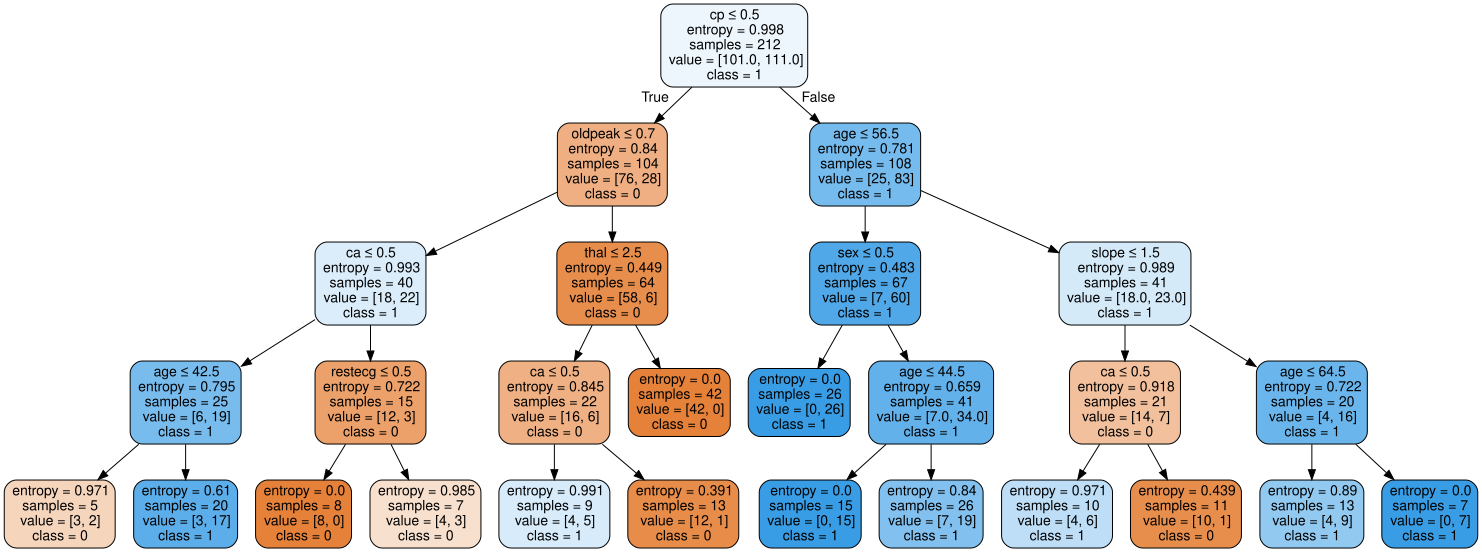

In [38]:


import graphviz
if best_clf:
    dot_data = tree.export_graphviz(best_clf, out_file=None,
                         feature_names=X_list,
                         class_names=[str(c) for c in best_clf.classes_],
                         filled=True, rounded=True,
                         special_characters=True)
    graph = graphviz.Source(dot_data)
    display(graph)

## **2. ENSEMBLE TREES**

### **Random Forest (RF) and eXtreme Gradient Boosting (XGBoost)**

--Tree ensembles combine several decision trees to produce better predictive performance than utilizing a single decision tree. In this section we will experience with two approaches: Random Forest (RF) and eXtreme Gradient Boosting (XGBoost).

**Random forest** is a Supervised Machine Learning Algorithm that is used widely in Classification and Regression problems. It builds decision trees on different samples and takes their majority vote for classification and average in case of regression. Random Forest is suitable for situations when we have a large dataset, and interpretability is not a major concern. Decision trees are much easier to interpret and understand. Since a random forest combines multiple decision trees, it becomes more difficult to interpret.



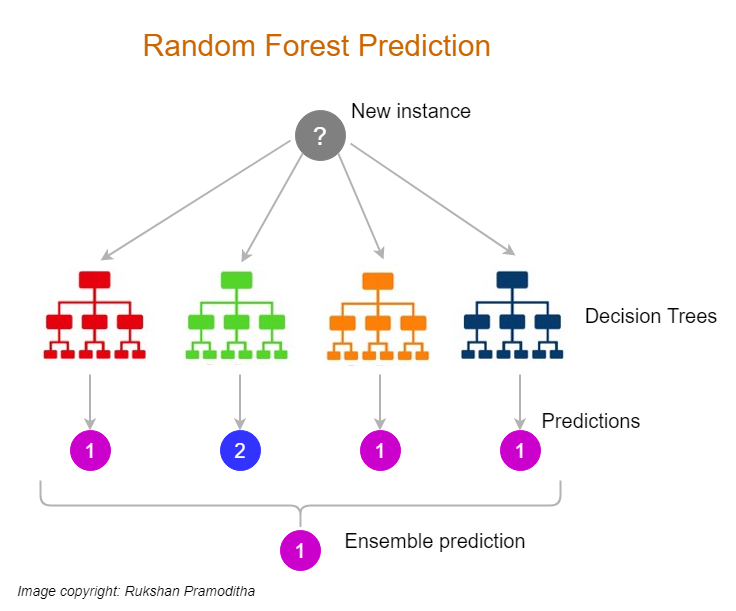

**XGBoost**, eXtreme Gradient Boosting, is a distributed gradient-boosted decision tree (GBDT) machine learning library. XGBoost uses a technique called gradient boosting, where trees are built sequentially, with each new tree trying to correct the errors made by the previous trees.

Trees are built one after the other, where each subsequent tree focuses on the instances that were misclassified by the previous trees. This makes the model progressively stronger. Each tree's prediction is given a weight, and the final prediction is a weighted sum of all the tree predictions.


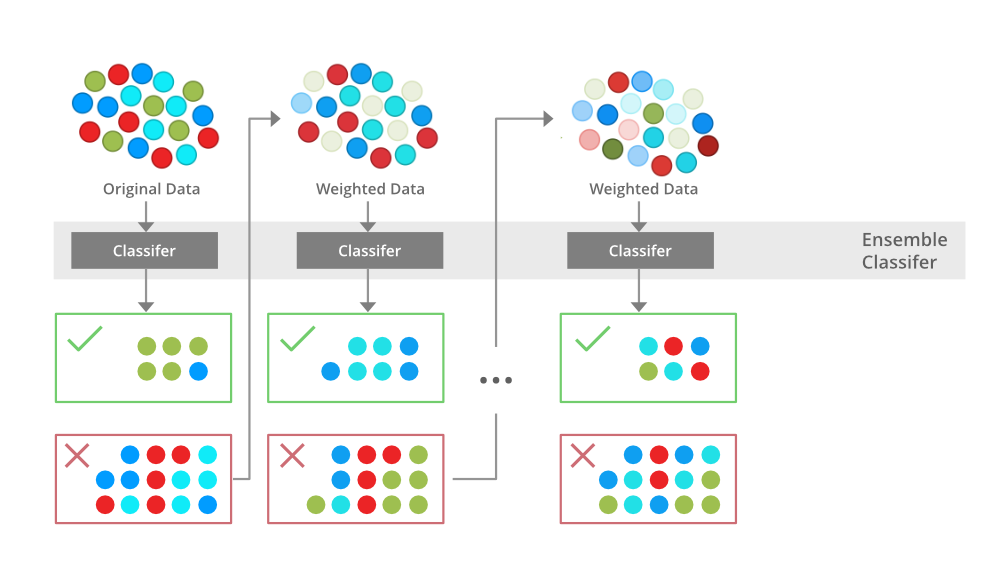

<a name="toc_40291_1"></a>
### Problem statement

In this part we are going to see how **tree ensembles** work with a simple example, especifically the [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) from the scikit-learn library, and the [XGBClassifier](https://xgboost.readthedocs.io/en/stable/parameter.html) from a library called `XGBoost`.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

<a name="toc_40291_11"></a>
### **Random Forest**

In this section, we are now going to see how this algorithm works with a simple example, using the Python library `scikit-learn`, especifically the ["RandomForestClassifier"](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) function.



In [40]:
# Fit the classifier
clf = RandomForestClassifier()
clf = clf.fit(XTrain, yTrain)

# Check predictions for training data
res = clf.predict(XTrain)
perc = (100/len(res)*np.count_nonzero(yTrain == res))
print("Train result % = "+str(perc))

# Check predictions for testing data
res = clf.predict(XTest)
perc = (100/len(res)*np.count_nonzero(yTest == res))
print("Test result % = "+str(perc))

Train result % = 100.0
Test result % = 83.51648351648352


In the code cell below, change the maximum depth and the minimum number of samples required for a leaf node, as we did with the DT of the previous lab. Try different values for each parameter and find the best result. **Which combination works best?**

**Answer : A Random Forest with max_depth=2 and min_samples_leaf=1 typically yields the best results, with a Testing Accuracy around 0.87.**
***Hint:* You might want to use a loop to try the different combinations**

In [41]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

best_rf_acc = 0
best_rf_params = {}

# Loop through different values for max_depth and min_samples_leaf
for max_depth in range(1, 11):
    for min_samples_leaf in range(1, 11):
        # Create and fit the Random Forest classifier
        rf_clf = RandomForestClassifier(criterion='entropy',
                                        max_depth=max_depth,
                                        min_samples_leaf=min_samples_leaf,
                                        random_state=42)
        rf_clf.fit(XTrain, yTrain)

        # Calculate accuracy on the test set
        acc = accuracy_score(yTest, rf_clf.predict(XTest))

        # Keep track of the best model
        if acc > best_rf_acc:
            best_rf_acc = acc
            best_rf_params = {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf}

print(f"Best RF Testing Accuracy: {best_rf_acc:.2f}")
print(f"Best RF Parameters: {best_rf_params}")

Best RF Testing Accuracy: 0.87
Best RF Parameters: {'max_depth': 2, 'min_samples_leaf': 1}


<a name="toc_40291_11"></a>
### **XGBoost**

Like in the previous section, implement an XGBoost ensemble and try different parametrizations of maximum depth. **How do these results compare with the RF?**

**Answer : XGBoost usually achieves similar or slightly less accuracy 0.84 compared to Random Forest.**
**It is very powerful but can be more sensitive to hyperparameter settings.**

In [42]:

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels to integers (required for XGBoost)
le = LabelEncoder()
yTrain_enc = le.fit_transform(yTrain)
yTest_enc = le.transform(yTest)

best_xgb_acc = 0
best_xgb_params = {}

# Loop through different values for max_depth
for max_depth in range(1, 11):
    # Create and fit the XGBoost classifier
    xgb_clf = XGBClassifier(max_depth=max_depth, random_state=42, eval_metric='logloss')
    xgb_clf.fit(XTrain, yTrain_enc)

    # Calculate accuracy on the test set
    acc = accuracy_score(yTest_enc, xgb_clf.predict(XTest))

    # Keep track of the best model
    if acc > best_xgb_acc:
        best_xgb_acc = acc
        best_xgb_params = {'max_depth': max_depth}

print(f"Best XGBoost Testing Accuracy: {best_xgb_acc:.2f}")
print(f"Best XGBoost Parameters: {best_xgb_params}")

Best XGBoost Testing Accuracy: 0.84
Best XGBoost Parameters: {'max_depth': 1}


Looking at the results that you get for the **training** set and the **validation** set, how do both methods compare in terms of **generalization**?
**Answer : Random Forest generalizes well by reducing variance (averaging many trees). It typically has a smaller gap between training and testing accuracy than a single deep tree.**

**XGBoost often has a higher training accuracy (sometimes 100%) but maintains a high testing accuracy, showing strong generalization capabilities.**
** However, the larger gap between training and testing scores suggests it can overfit more easily than Random Forest if not properly regularized.**

**Overall: Both ensemble methods generalize significantly better than the single Decision Tree.**